In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback 
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers.schedules import ExponentialDecay


In [2]:
file_path = r"train_araCovid_sentiment.tsv"
df1 = pd.read_csv(file_path, encoding='utf-8', sep='\t')
df1.head()

,Unnamed: 0,Text,sentiment
0,0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد ي...,Positive
1,1,ههههه هذا مكان اخطر من كورونا فايروس. 😂😂🔥.,Positive
2,2,خايفه يجيبوا لقاح الكورونا وما يكفينا ويقوموا ...,Positive
3,3,الطواقي وشخبار الطرد لحل يطلعون اشاعات هههههه...,Positive
4,4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كو...,Positive


In [3]:
from nltk.corpus import stopwords
import nltk
from nltk.corpus import stopwords

# Function to clean text
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove hachtags
    text = re.sub(r'#\w+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove emojis
    text = re.sub(r'[^\w\s,]', '', text)
    # Remove numbers with 3 or more consecutive digits
    text = re.sub(r'\d{3,}', '', text)
    # Remove extra spaces
    # Remove extra spaces

    # Remove stop words (Arabic) using nltk
    try:
        arabic_stopwords = set(stopwords.words('arabic'))
    except LookupError:
        nltk.download('stopwords')
        arabic_stopwords = set(stopwords.words('arabic'))
    text = ' '.join([word for word in text.split() if word not in arabic_stopwords])
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove non-Arabic words
    text = re.sub(r'[^ا-ي\s]', '', text)
    
    return text

# Apply cleaning function to the 'cleaned_text' column
df1['cleaned_text'] = df1['Text'].apply(clean_text)

# Remove rows with empty 'cleaned_text' after cleaning
df1 = df1[df1['cleaned_text'].str.strip() != '']

# Display the cleaned DataFrame
df1.head()


,Unnamed: 0,Text,sentiment,cleaned_text
0,0,*علاج ڤايروس الكورونا* كل يوم الصبح الواحد ي...,Positive,علاج ايروس الكورونا يوم الصبح الواحد يقرط ثلات...
1,1,ههههه هذا مكان اخطر من كورونا فايروس. 😂😂🔥.,Positive,ههههه مكان اخطر كورونا فايروس
2,2,خايفه يجيبوا لقاح الكورونا وما يكفينا ويقوموا ...,Positive,خايفه يجيبوا لقاح الكورونا يكفينا ويقوموا يزيد...
3,3,الطواقي وشخبار الطرد لحل يطلعون اشاعات هههههه...,Positive,الطواقي وشخبار الطرد لحل يطلعون اشاعات ههههههه...
4,4,@Waleed_Albashaa هههههههه انتظر بعد ما تخلص كو...,Positive,هههههههه انتظر تخلص كورونا عادي


In [4]:
# Combine all comments into a single string
all_texts = " ".join(df1['cleaned_text'].dropna().astype(str))

# Extract all words using regex
words = re.findall(r'\S+', all_texts)
    
# Get unique words
corpus = set(words)

print("All unique words in the 'cleaned_text' column:")
print(corpus)

All unique words in the 'cleaned_text' column:
{'المس', 'نوصلو', 'عقود', 'رهابي', 'ازح', 'ههههههههههههههههههههههههههههههههههههه', 'اجتماعاته', 'العود', 'انفوجرافيك', 'وطلبت', 'لوافد', 'الاولاد', 'والذن', 'تبث', 'ردا', 'تنفسي', 'بدنا', 'مكان', 'دامان', 'بعدم', 'حصنو', 'دموعي', 'حصر', 'بالنظافة', 'شهور', 'بنتي', 'قلتلوا', 'توحد', 'جدوا', 'ومصر', 'تحط', 'التكريمات', 'بقضا', 'سيطول', 'طعمة', 'ماكانش', 'برسال', 'وحياة', 'لايغادر', 'تانية', 'واعتصمت', 'فضلكم', 'وعشرين', 'منهج', 'والمحب', 'مصابا', 'واشفه', 'بالفراد', 'نتخرج', 'نصادر', 'مهندس', 'وللوقايه', 'تكون', 'الكرونا', 'يتصل', 'صبي', 'نخف', 'عباس', 'المستعجلة', 'الاعلامية', 'برغش', 'خرى', 'الاشقا', 'الطويل', 'الاطفال', 'تلقينا', 'التكبير', 'لكورونا', 'وزدهم', 'والقهاوي', 'الحساب', 'يتفادين', 'قياسية', 'موحد', 'والسوق', 'نعيشو', 'عودته', 'بجانبه', 'ناصحة', 'اهخ', 'ويسيطر', 'باللغة', 'والغمة', 'للثوم', 'يكافحون', 'اطلع', 'بالمحافظاتفمش', 'والعافية', 'الحرية', 'القاعدة', 'والوعي', 'رعاية', 'لكنه', 'كثرة', 'والمحن', 'شهادة', 'توجيه', 'وكثروا

In [14]:
len(corpus)

12665

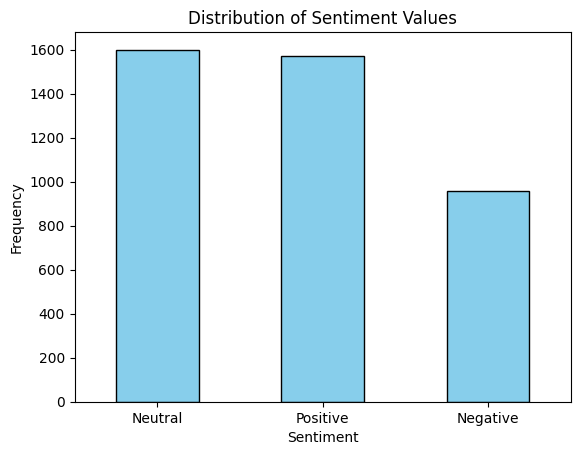

In [5]:
df1['sentiment'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    
# Add labels and title
plt.title('Distribution of Sentiment Values')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.xticks(rotation=0)  
plt.show()


In [6]:
new_df = df1[['cleaned_text', 'sentiment']]
new_df.head()
new_df.shape

(4128, 2)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=12665)  # Limit to top 12855 features for efficiency

# Fit and transform the cleaned_text column
tfidf_matrix = tfidf_vectorizer.fit_transform(new_df['cleaned_text'])

# Convert the TF-IDF matrix to a DataFrame for better readability
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())


t=tfidf_matrix.toarray()

In [11]:
tfidf_df.head()

,الصبر,الصين,الكورونا,الله,اللهم,اللي,الموت,الوبا,ان,شي,فيروس,كورونا,يارب,يروح,يلعن
0,0.0,0.0,0.757605,0.27518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.591871,0.0,0.0
1,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.0
2,0.0,0.0,1.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.0


In [17]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(t, new_df['sentiment'], test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3302, 12655)
Testing data shape: (826, 12655)


In [18]:

# Convert y to 0, 1, 2
# Map string labels to integers
label_mapping = {"Negative": 0, "Neutral": 1, "Positive": 2}
y_train = np.array([label_mapping[label] for label in y_train])
y_test = np.array([label_mapping[label] for label in y_test])

# One-hot encode the labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [21]:
y_test[2]

0

In [22]:
y_train_cat[1]

array([0., 0., 1.])

Accuracy: 0.8861985472154964

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.81      0.86       189
           1       0.81      0.96      0.88       298
           2       0.97      0.86      0.91       339

    accuracy                           0.89       826
   macro avg       0.89      0.88      0.88       826
weighted avg       0.90      0.89      0.89       826



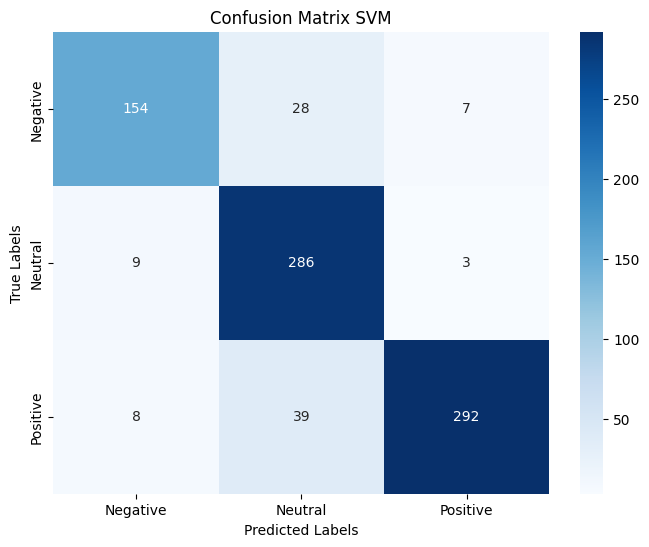

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize the SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix SVM')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Accuracy: 0.8208232445520581

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.81       189
           1       0.79      0.82      0.80       298
           2       0.84      0.84      0.84       339

    accuracy                           0.82       826
   macro avg       0.82      0.82      0.82       826
weighted avg       0.82      0.82      0.82       826



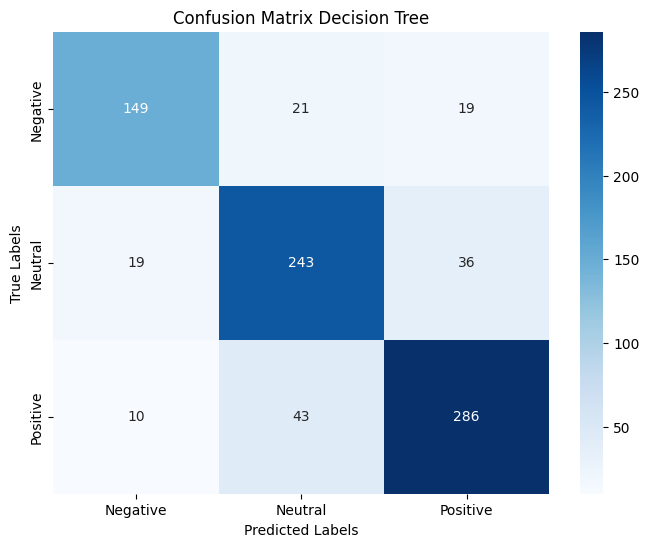

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix Decision Tree')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Accuracy: 0.8619854721549637

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.80      0.84       189
           1       0.79      0.91      0.85       298
           2       0.93      0.86      0.89       339

    accuracy                           0.86       826
   macro avg       0.87      0.85      0.86       826
weighted avg       0.87      0.86      0.86       826



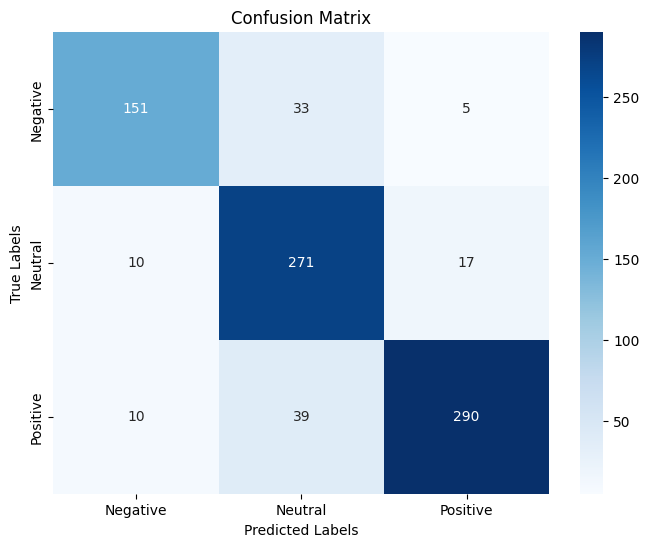

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=71)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

c:\Users\DELL\Desktop\SA\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:25:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8389830508474576

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.78      0.83       189
           1       0.78      0.89      0.83       298
           2       0.88      0.83      0.86       339

    accuracy                           0.84       826
   macro avg       0.85      0.83      0.84       826
weighted avg       0.84      0.84      0.84       826



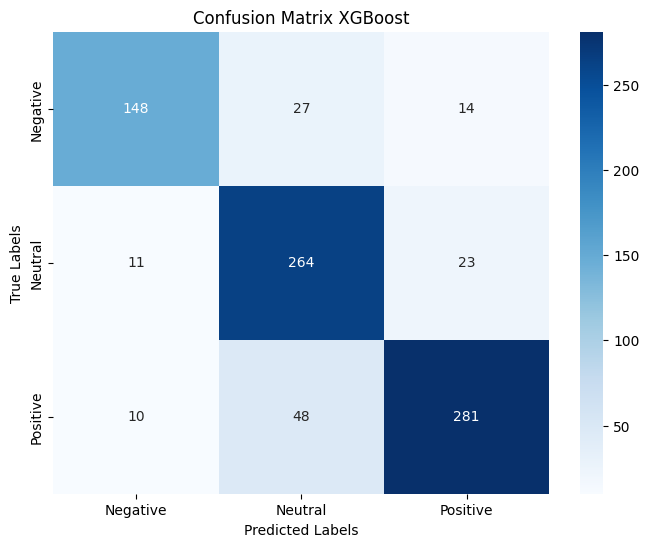

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Initialize the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix XGBoost')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Epoch 1/100


c:\Users\DELL\Desktop\SA\myenv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3960 - loss: 1.0900Epoch 1: Test accuracy = 0.7010, Test loss = 0.9933
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3977 - loss: 1.0893 - val_accuracy: 0.6979 - val_loss: 0.9995
Epoch 2/100
87/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6300 - loss: 0.9487Epoch 2: Test accuracy = 0.8596, Test loss = 0.7244
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6317 - loss: 0.9447 - val_accuracy: 0.8308 - val_loss: 0.7343
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7211 - loss: 0.7224Epoch 3: Test accuracy = 0.8705, Test loss = 0.5309
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7213 - loss: 0.7220 - val_accuracy: 0.8610 - val_loss: 0.5445
Epoch 4/100
85/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8221 - loss: 0.5408Epoch 4: Test accuracy = 0.8789, Test loss = 0.4403
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8209 - loss: 0.5411 - val_accuracy: 0.8610 - val_loss: 0.4522
Epoch 5/

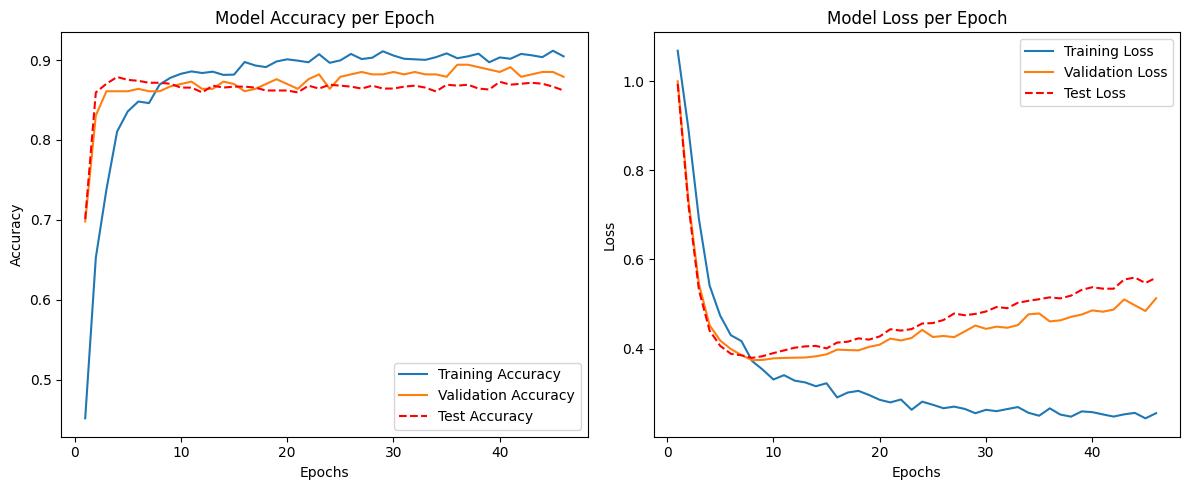

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Final Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       189
           1       0.85      0.87      0.86       298
           2       0.89      0.89      0.89       339

    accuracy                           0.87       826
   macro avg       0.87      0.86      0.86       826
weighted avg       0.87      0.87      0.87       826



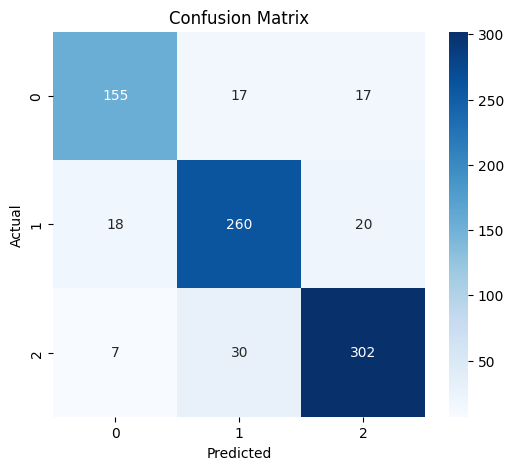

In [12]:

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Custom callback to evaluate on test data after each epoch
class TestPerformanceCallback(Callback):
    def __init__(self, X_test, y_test_cat):
        super().__init__()
        self.X_test = X_test
        self.y_test_cat = y_test_cat
        self.test_accuracies = []
        self.test_losses = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X_test, self.y_test_cat, verbose=0)
        self.test_losses.append(loss)
        self.test_accuracies.append(acc)
        print(f"Epoch {epoch+1}: Test accuracy = {acc:.4f}, Test loss = {loss:.4f}")

# Define the model model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.0001)),
    Dropout(0.5),
    Dense(8, activation='relu', kernel_regularizer=l2(0.0001)),
    Dropout(0.5),
    Dense(3, activation='softmax', kernel_regularizer=l2(0.0001))
])


# Compile the model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
test_callback = TestPerformanceCallback(X_test, y_test_cat)
reduce_lr = ReduceLROnPlateau(monitor='accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
# Define a learning rate schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.00025,
    decay_steps=1000,
    decay_rate=0.5,
    staircase=True
)
# Train the model (with validation split and test tracking)
history = model.fit(X_train, y_train_cat,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop, test_callback])


# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

# Plot training, validation, and test metrics
epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(epochs_range, test_callback.test_accuracies, label='Test Accuracy', linestyle='dashed', color='red')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.plot(epochs_range, test_callback.test_losses, label='Test Loss', linestyle='dashed', color='red')
plt.title('Model Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predict and evaluate final model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_12392\3527868133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=training_times, palette='viridis')


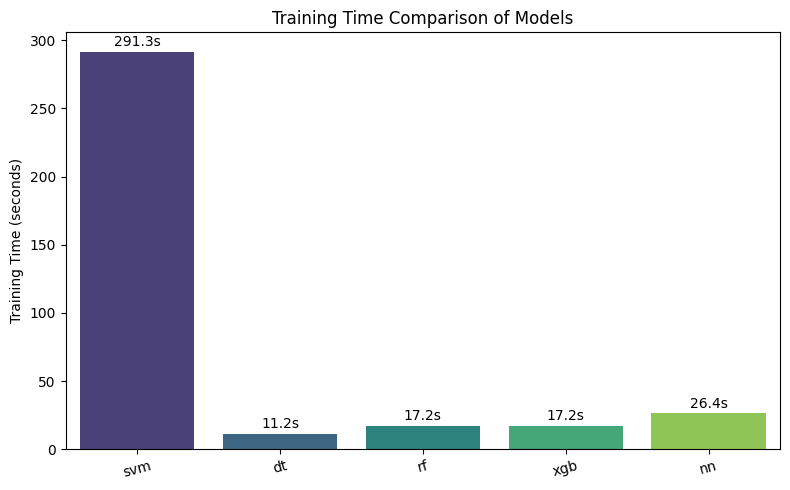

In [28]:
# Plotting the training times for each model
model_names = ['SVM', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network']
training_times = [4*60 + 51.3, 11.2, 17.2, 17.2, 26.4]  # times in seconds

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=training_times, palette='viridis')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison of Models')
for i, time in enumerate(training_times):
    plt.text(i, time + 2, f"{time:.1f}s", ha='center', va='bottom', fontsize=10)
# Custom x-tick labels to show "4 min 51.3s" for SVM
custom_labels = ['svm', 'dt', 'rf', 'xgb', 'nn']
plt.xticks(ticks=range(len(model_names)), labels=custom_labels, rotation=15)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_7084\207238590.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='mako')


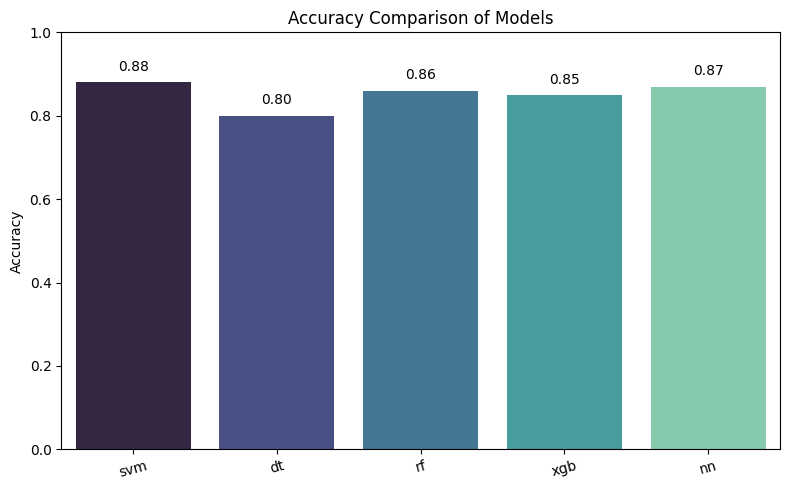

In [8]:
# Accuracies for each model (from previous evaluation outputs)
accuracies = [
    0.88,  # SVM
    0.80,  # Decision Tree
    0.86,  # Random Forest
    0.85,  # XGBoost
    0.87   # Neural Network
]
model_names = ['SVM', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network']
custom_labels = ['svm', 'dt', 'rf', 'xgb', 'nn']
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='mako')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Models')
plt.ylim(0, 1)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', va='bottom', fontsize=10)
plt.xticks(ticks=range(len(model_names)), labels=custom_labels, rotation=15)
plt.tight_layout()
plt.show()